## Dependencias

In [1]:
import os
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
import random

pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.3f}'.format

## ETL

In [2]:
def carga_json(path:str)->pd.DataFrame:

    with open(path, 'r', encoding='utf-8') as f:
        
        data = json.load(f)
        
    measurements = data['pollutionMeasurements']['date']

    rows = []
    for fecha, var in measurements.items():
        for parametro, estaciones in var.items():
            for estacion, valor in estaciones.items():
                if valor == '':
                    valor = np.nan
                rows.append({
                    'fecha': fecha,
                    'estacion' : estacion,
                    'parametro' : parametro,
                    'valor' : valor
                })
                
                
    df = pd.DataFrame(rows)
    return df

In [3]:
historicos = r"D:\Diplomado\TecnicasCognitivasIntroduccionABD\Prácticas\Práctica III\datos\datos\históricos"

dic_df = {}

for js in os.listdir(historicos):
    aux_path = os.path.join(historicos,js)
    
    dic_df[f'{js.split('.')[0]}'] = carga_json(aux_path)
    

In [4]:
estaciones = pd.concat([d for _,d in dic_df.items()], axis=0)

print(estaciones.shape)
estaciones.head()

(8924016, 4)


,fecha,estacion,parametro,valor
0,2013-01-01 01:00,ACO,RH,58
1,2013-01-01 01:00,MON,RH,57
2,2013-01-01 01:00,CHO,RH,NaN
3,2013-01-01 01:00,CUA,RH,62
4,2013-01-01 01:00,CUT,RH,NaN


In [5]:
# Filtraremos solo la estación de la FAC y la temperatura

df = estaciones.loc[(estaciones['estacion'] == 'FAC')&(estaciones['parametro'] == 'TMP')]

In [6]:
df.head()

,fecha,estacion,parametro,valor
23,2013-01-01 01:00,FAC,TMP,NaN
96,2013-01-01 02:00,FAC,TMP,NaN
169,2013-01-01 03:00,FAC,TMP,NaN
242,2013-01-01 04:00,FAC,TMP,NaN
315,2013-01-01 05:00,FAC,TMP,NaN


## EDA

In [7]:
# Revisamos los nulos

df.isna().sum() / df.shape[0]

fecha       0.000
estacion    0.000
parametro   0.000
valor       0.156
dtype: float64

In [8]:
# Nos quedamos solo con la fecha ya que se pide la predicción de la temp promedio por día del mes siguiente

df['fecha'] = df['fecha'].str[:10]
df['fecha'] = pd.to_datetime(df['fecha'], format='%Y-%m-%d')

C:\Users\azayas\AppData\Local\Temp\ipykernel_23040\3293543840.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['fecha'] = df['fecha'].str[:10]
C:\Users\azayas\AppData\Local\Temp\ipykernel_23040\3293543840.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['fecha'] = pd.to_datetime(df['fecha'], format='%Y-%m-%d')


In [9]:
# Eliminamos las columnas que no necesitamos

df.drop(columns=['estacion','parametro'], inplace=True)

C:\Users\azayas\AppData\Local\Temp\ipykernel_23040\1319025014.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['estacion','parametro'], inplace=True)


In [10]:
df.dropna(inplace=True)

C:\Users\azayas\AppData\Local\Temp\ipykernel_23040\1379821321.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


In [11]:
df.sort_values('fecha', inplace=True)

df['valor'] = df['valor'].astype(float)

C:\Users\azayas\AppData\Local\Temp\ipykernel_23040\991264627.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values('fecha', inplace=True)
C:\Users\azayas\AppData\Local\Temp\ipykernel_23040\991264627.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['valor'] = df['valor'].astype(float)


In [12]:
# Agruparemos por día ya que no necesitaremos las horas por la naturaleza del problema

df = df.groupby('fecha').mean().reset_index()

En la gráfica anterior notamos que hay fechas en las cuales no se registraron

In [13]:
# Ya es díario
df['fecha'].diff().mean()

Timedelta('1 days 03:30:36')

In [14]:
df.describe(percentiles=[0.01, 0.25,0.75,0.99])

,fecha,valor
count,3201,"3,201.000"
mean,2018-01-19 13:22:05.960637184,17.012
min,2013-04-14 00:00:00,6.429
1%,2013-05-18 00:00:00,10.725
25%,2015-08-15 00:00:00,15.342
50%,2017-11-21 00:00:00,17.262
75%,2020-06-18 00:00:00,18.812
99%,2023-03-29 00:00:00,21.958
max,2023-04-30 00:00:00,24.417
std,NaN,2.502


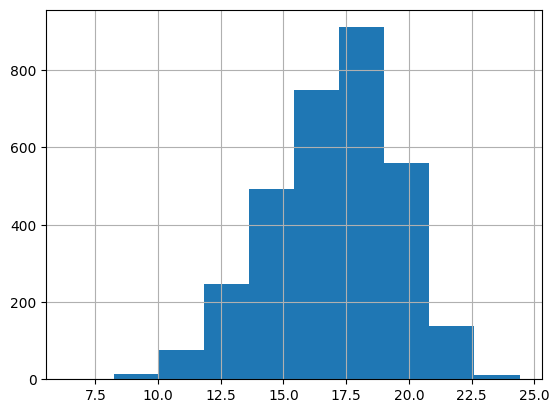

In [15]:
df['valor'].hist()
plt.show()

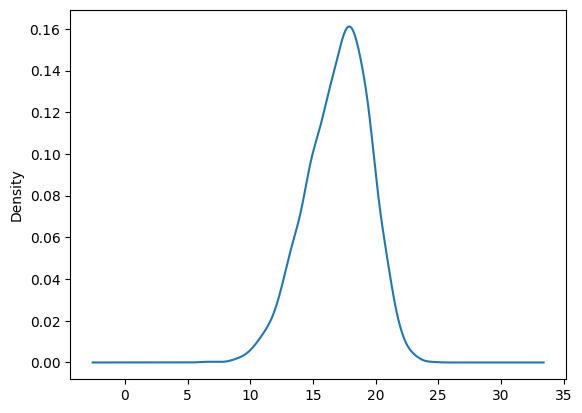

In [16]:
df['valor'].plot(kind='kde')
plt.show()

In [17]:
date_index = pd.date_range(
    start=df['fecha'].min(),
    end=df['fecha'].max(),
)

In [18]:
df = df.set_index('fecha').reindex(date_index)

In [19]:
fig = px.line(
    df.reset_index(),
    x='index',
    y='valor',
    title='Temperatura promedio diaria en la estación de la FAC',
)

fig.show()

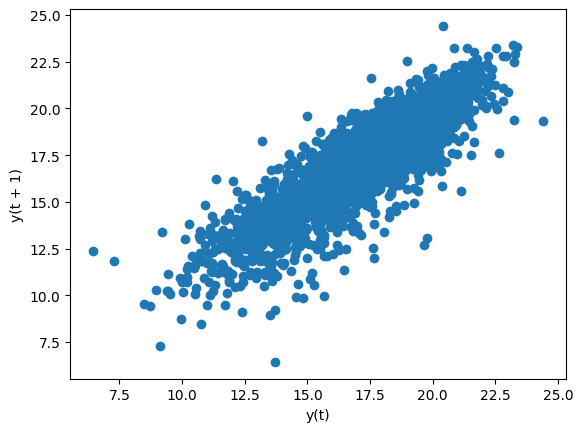

In [20]:
pd.plotting.lag_plot(df['valor'])
plt.show()

Con las gráficas anteriores, notamos lo siguiente:
* Se tienen vacíos grandes y pequeños.
* La distribución de la temperatura se acerca a una Gaussiana.
* La relación entre los días pasados y siguintes son lineales.

## Missings

Como notamos en la gráfica anterior, hay datos faltantes en largos periodos. Como alternativa, analizaremos otras estaciones cercanas para poder imputar los datos.

In [21]:
cat_estaciones = pd.read_csv(r"D:\Diplomado\TecnicasCognitivasIntroduccionABD\Prácticas\Práctica III\datos\datos\catálogos\cat_estacion.csv",skiprows=1,encoding='latin-1')

cat_estaciones

,cve_estac,nom_estac,longitud,latitud,alt,obs_estac,id_station
0,ACO,Acolman,-98.912,19.636,"2,198.000",NaN,484150020109
1,AJU,Ajusco,-99.163,19.154,"2,942.000",NaN,484090120400
2,AJM,Ajusco Medio,-99.208,19.272,"2,548.000",NaN,484090120609
3,ARA,Aragón,-99.075,19.470,"2,200.000",Finalizó operación en 2010,484090050301
4,ATI,Atizapan,-99.254,19.577,"2,341.000",NaN,484150130101
...,...,...,...,...,...,...,...
64,VIF,Villa de las Flores,-99.097,19.658,"2,242.000",NaN,484150200109
65,XAL,Xalostoc,-99.082,19.526,"2,160.000",NaN,484150330415
66,XCH,Xochimilco,-99.118,19.267,"2,243.000",Finalizó operación en 1999,484090130102
67,FAR,FES Aragón,-99.046,19.474,"2,230.000",NaN,484800150584


In [22]:
fig = px.scatter_geo(
    cat_estaciones,
    lat='latitud',
    lon='longitud',
    hover_name='cve_estac',
    text='cve_estac'
)

fig.update_traces(textposition='top center', mode='markers+text')

Con el mapa anterior notamos que las estaciones más cercanas son ATI, VAL, AZC, TAC, SHA y TLA.

### Imputación basada en cercanía geográfica

In [23]:
cat_estaciones.loc[cat_estaciones['cve_estac']=='CUT']

,cve_estac,nom_estac,longitud,latitud,alt,obs_estac,id_station
16,CUT,Cuautitlán,-99.199,19.722,"2,263.000",NaN,484150950109


In [24]:
est_ = estaciones.loc[estaciones['parametro'] == 'TMP','estacion'].unique().tolist()

cat_aux = cat_estaciones.loc[cat_estaciones['cve_estac'].isin(est_), ['cve_estac','longitud','latitud']]

cat_aux.head()

,cve_estac,longitud,latitud
0,ACO,-98.912,19.636
1,AJU,-99.163,19.154
2,AJM,-99.208,19.272
6,BJU,-99.160,19.370
11,CHO,-98.886,19.267


In [25]:
from sklearn.neighbors import BallTree

coords = np.radians(cat_aux[['latitud','longitud']])

tree = BallTree(coords, metric='haversine')

dist, idx = tree.query(np.radians([[19.482,99.244]]), k=4)

In [26]:
print("######### Las cuatro estaciones más cercanas son:")
display(cat_aux.iloc[idx[0]])

######### Las cuatro estaciones más cercanas son:


,cve_estac,longitud,latitud
16,CUT,-99.199,19.722
64,VIF,-99.097,19.658
57,TLA,-99.205,19.529
0,ACO,-98.912,19.636


In [27]:
OPC = estaciones[(estaciones['estacion'].isin(['TLA','CUT','VIF','TLA','ACO']))&(estaciones['parametro'] == 'TMP')].copy()

OPC['valor'] = OPC['valor'].astype(float)

OPC['fecha'] = OPC['fecha'].str[:10]

OPC['fecha'] = pd.to_datetime(OPC['fecha'])
OPC.info()

<class 'pandas.core.frame.DataFrame'>
Index: 362112 entries, 18 to 313854
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   fecha      362112 non-null  datetime64[ns]
 1   estacion   362112 non-null  object        
 2   parametro  362112 non-null  object        
 3   valor      303337 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 13.8+ MB


In [28]:
date_index_OPC = pd.date_range(
    start=OPC['fecha'].min(),
    end=OPC['fecha'].max()
)

# OPC = OPC.set_index('fecha').reindex(date_index_TLA)

OPC_clean = OPC.groupby(['estacion','fecha'], as_index=False)['valor'].mean()

OPCS_ = pd.concat([
    d.set_index('fecha')
     .reindex(date_index_OPC)
     .rename(columns={'valor': f"valor_{d['estacion'].iloc[0]}"})
     .drop(columns=['estacion'])
    for _, d in OPC_clean.groupby('estacion')
], axis=1)

OPCS_.head(10)

,valor_ACO,valor_CUT,valor_TLA,valor_VIF
2013-01-01,13.525,NaN,14.978,14.537
2013-01-02,12.496,NaN,13.729,13.338
2013-01-03,12.826,NaN,12.732,12.908
2013-01-04,12.638,NaN,13.414,12.487
2013-01-05,12.346,NaN,13.700,12.467
2013-01-06,12.258,NaN,16.243,12.833
2013-01-07,11.979,NaN,13.246,12.671
2013-01-08,13.400,NaN,15.963,14.729
2013-01-09,16.338,NaN,16.922,17.688
2013-01-10,14.483,NaN,18.300,16.033


In [29]:
# Misma fechas de FAC

OPCS_ = OPCS_.loc[df.index.date.min(): df.index.date.max()].copy()

In [30]:
df.rename(columns={'valor':'valor_FAC'}, inplace=True)

df = pd.concat([df,OPCS_ ], axis=1)

In [31]:
fig = px.line(
    df.reset_index(names='fecha'),
    x='fecha',
    y=['valor_TLA','valor_ACO','valor_CUT','valor_TLA','valor_VIF', 'valor_FAC']
)

fig.show()

In [32]:
corr_matrix = df.corr(numeric_only=True)

# Create heatmap
fig = px.imshow(corr_matrix, 
                text_auto=True, 
                aspect="auto", 
                color_continuous_scale='RdBu_r',
                zmin=-1, zmax=1)
fig.show()

Notamos que las estaciones cercanas tienen una correlación estadísticamente significativa. Ahora haremos una prueba de hipótesis usando Kolmogorov-Smirnoff para comparar las distribuciones

In [33]:
from scipy.stats import ks_2samp

stats_summ = {}

for c in [i for i in df.columns if i != 'valor_FAC']:
    print(f"Columna: {c}")
    stat, pval = ks_2samp(
        df['valor_FAC'].dropna(),
        df[c].dropna()
    )
    stats_summ[c] = {
        'stat': stat,
        'pval': pval
    }

stats_summ = pd.DataFrame(stats_summ).T
    

Columna: valor_ACO
Columna: valor_CUT
Columna: valor_TLA
Columna: valor_VIF


In [34]:
stats_summ.sort_values(by=['stat','pval'], ascending=[1,1])

,stat,pval
valor_VIF,0.031,0.099
valor_TLA,0.054,0.000
valor_ACO,0.164,0.000
valor_CUT,0.248,0.000


Como podemos observar en la tabla anterior, la correlación es alta en casi todos los casos. Pero al hacer la prueba de Kolmogorov-Smirnoff, notamos que la hipótesis nula (que la distribución sea la misma) se rechaza para casi todos los casos con excepción de la estación VIF. Haremos feature engineering para poder crear variables suficientes para que el modelo apreda e imputemos los datos faltantes.

### Feature Engineering para Imputación

Para no generar data leakage, no utilizaremos la variable `FAC` en este paso.

In [35]:
df.sort_index(inplace=True)

In [36]:
columnas = [c for c in df.columns if 'FAC' not in c]
columnas

['valor_ACO', 'valor_CUT', 'valor_TLA', 'valor_VIF']

In [37]:
# Lags de un solo día para imputación iterativa

for c in columnas:
    for lag in [1]:
        df[f'{c}_lag{lag}'] = df[c].shift(lag)

In [38]:
df['dia_semana'] = df.index.dayofweek
df['mes'] = df.index.month
df['dia_año'] = df.index.dayofyear
df['semana_año'] = df.index.isocalendar().week

In [39]:
# Encoding cíclico

df['mes_sin'] = np.sin(2*np.pi*df['mes']/12)
df['mes_cos'] = np.cos(2*np.pi*df['mes']/12)

In [40]:
df['promedio_estaciones'] = df[columnas].mean(axis=1)
df['std_estaciones'] = df[columnas].std(axis=1)

In [41]:
df['FAC_missing'] = df['valor_FAC'].isna().astype(int)

### Imputación Iterativa

In [42]:
cols_core = [
    'valor_FAC', 'valor_VIF', 'valor_ACO', 'valor_TLA', 'valor_CUT',
    'valor_VIF_lag1', 'valor_ACO_lag1',
    'mes_sin', 'mes_cos','dia_semana','mes','dia_año',
    'promedio_estaciones', 'std_estaciones'
]

df[cols_core]

,valor_FAC,valor_VIF,valor_ACO,valor_TLA,valor_CUT,valor_VIF_lag1,valor_ACO_lag1,mes_sin,mes_cos,dia_semana,mes,dia_año,promedio_estaciones,std_estaciones
2013-04-14,20.733,20.963,20.100,NaN,NaN,NaN,NaN,0.866,-0.500,6,4,104,20.531,0.610
2013-04-15,20.250,21.346,20.058,20.133,NaN,20.963,20.100,0.866,-0.500,0,4,105,20.512,0.723
2013-04-16,21.425,22.417,21.354,25.677,NaN,21.346,20.058,0.866,-0.500,1,4,106,23.149,2.253
2013-04-17,21.879,22.700,21.900,22.500,NaN,22.417,21.354,0.866,-0.500,2,4,107,22.367,0.416
2013-04-18,22.121,23.292,22.312,22.827,NaN,22.700,21.900,0.866,-0.500,3,4,108,22.810,0.490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-04-26,17.616,20.800,18.300,21.350,20.542,22.287,NaN,0.866,-0.500,2,4,116,20.248,1.342
2023-04-27,19.742,20.654,18.433,21.338,18.833,20.800,18.300,0.866,-0.500,3,4,117,19.815,1.402
2023-04-28,19.671,20.633,18.450,21.067,20.233,20.654,18.433,0.866,-0.500,4,4,118,20.096,1.149
2023-04-29,19.025,19.142,17.100,20.188,19.083,20.633,18.450,0.866,-0.500,5,4,119,18.878,1.289


In [43]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

imputer = IterativeImputer(
    estimator=RandomForestRegressor(
        n_estimators=50,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    max_iter=10,
    random_state=42,
    initial_strategy='mean'
)


In [44]:
df_imputed_iterative_rf = df.copy()

df_imputed_iterative_rf[cols_core] = imputer.fit_transform(df[cols_core])

c:\Users\azayas\Diplomado\myenv\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning:

[IterativeImputer] Early stopping criterion not reached.



In [45]:
fig = px.line(
    df_imputed_iterative_rf.reset_index(names='fecha'),
    x='fecha',
    y=['valor_FAC']
)

fig.show()

In [46]:
aux_df = df_imputed_iterative_rf[['valor_VIF', 'valor_ACO', 'valor_TLA', 'valor_CUT']].copy()

aux_df.columns = ['RF_VIF', 'RF_ACO', 'RF_TLA', 'RF_CUT']

df_comb = pd.concat([df,aux_df],axis=1)

df_comb.drop(columns=['valor_VIF', 'valor_ACO', 'valor_TLA', 'valor_CUT'], inplace=True)
df_comb.head(10)

,valor_FAC,valor_ACO_lag1,valor_CUT_lag1,valor_TLA_lag1,valor_VIF_lag1,dia_semana,mes,dia_año,semana_año,mes_sin,mes_cos,promedio_estaciones,std_estaciones,FAC_missing,RF_VIF,RF_ACO,RF_TLA,RF_CUT
2013-04-14,20.733,NaN,NaN,NaN,NaN,6,4,104,15,0.866,-0.500,20.531,0.610,0,20.963,20.100,20.824,20.302
2013-04-15,20.250,20.100,NaN,NaN,20.963,0,4,105,16,0.866,-0.500,20.512,0.723,0,21.346,20.058,20.133,19.957
2013-04-16,21.425,20.058,NaN,20.133,21.346,1,4,106,16,0.866,-0.500,23.149,2.253,0,22.417,21.354,25.677,19.394
2013-04-17,21.879,21.354,NaN,25.677,22.417,2,4,107,16,0.866,-0.500,22.367,0.416,0,22.700,21.900,22.500,20.867
2013-04-18,22.121,21.900,NaN,22.500,22.700,3,4,108,16,0.866,-0.500,22.810,0.490,0,23.292,22.312,22.827,20.731
2013-04-19,20.121,22.312,NaN,22.827,23.292,4,4,109,16,0.866,-0.500,20.017,0.906,0,19.421,19.571,21.060,19.210
2013-04-20,19.621,19.571,NaN,21.060,19.421,5,4,110,16,0.866,-0.500,18.349,0.419,0,18.179,18.042,18.826,18.270
2013-04-21,21.008,18.042,NaN,18.826,18.179,6,4,111,16,0.866,-0.500,20.772,0.233,0,20.696,20.588,21.033,20.934
2013-04-22,20.829,20.588,NaN,21.033,20.696,0,4,112,17,0.866,-0.500,21.001,0.127,0,21.008,20.871,21.125,21.204
2013-04-23,19.012,20.871,NaN,21.125,21.008,1,4,113,17,0.866,-0.500,20.455,0.470,0,20.042,20.967,20.357,20.109


### Imputación con Redes Neuronales

In [47]:
df_model = df_comb.copy()
df_model = df_model.sort_index()


for lag in [1, 7, 14]:
    df_model[f'lag_{lag}'] = df_model['valor_FAC'].shift(lag)

features = [
    'RF_VIF', 'RF_ACO', 'RF_TLA', 'RF_CUT',
    'mes_sin', 'mes_cos',
    'lag_1', 'lag_7', 'lag_14'
]

train_df = df_model[df_model['valor_FAC'].notna()].copy()

train_df = train_df.dropna(subset=features)

sc = StandardScaler()

X_train = sc.fit_transform(train_df[features])
y_train = train_df['valor_FAC']

split = int(0.8 * len(X_train))

X_tr, X_val = X_train[:split], X_train[split:]
y_tr, y_val = y_train.iloc[:split], y_train.iloc[split:]

In [48]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)  # Single output
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Step 5: Train the Model
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

c:\Users\azayas\Diplomado\myenv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 180.9308 - mae: 12.8014 - val_loss: 45.3784 - val_mae: 5.9502
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 28.0264 - mae: 4.3674 - val_loss: 12.2241 - val_mae: 2.9350
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10.3208 - mae: 2.5678 - val_loss: 4.3735 - val_mae: 1.7066
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.8727 - mae: 1.7673 - val_loss: 2.4488 - val_mae: 1.2605
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.1226 - mae: 1.4093 - val_loss: 1.8184 - val_mae: 1.0735
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.2379 - mae: 1.1791 - val_loss: 1.4986 - val_mae: 0.9646
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.7157 - mae: 1.0199 - val_loss: 1.1840 - val_mae: 0.8454
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3680 - mae: 0.9063 - val_loss: 1.1529 - val_mae: 0.8262
Epoch 9/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1360 

In [49]:
df_imputed = df_model.copy()

for i in range(len(df_imputed)):
    
    if pd.isna(df_imputed.iloc[i]['valor_FAC']):
        
        # actualizar lags dinámicamente
        for lag in [1, 7, 14]:
            df_imputed.iloc[i, df_imputed.columns.get_loc(f'lag_{lag}')] = \
                df_imputed.iloc[i - lag]['valor_FAC']
        
        row = df_imputed.loc[df_imputed.index[i], features]
        
        # # si aún hay NaN → saltar
        if row.isna().any():
            continue
        
        row_df = pd.DataFrame([row], columns=features)
        row_scaled = sc.transform(row_df)
        
        pred = model.predict(row_scaled, verbose=0)[0][0]
        
        df_imputed.iloc[i, df_imputed.columns.get_loc('valor_FAC')] = pred

In [50]:
df_imputed['valor_FAC'].isna().sum()

np.int64(0)

In [51]:
aux = pd.concat([df_imputed_iterative_rf[['valor_FAC']], df_imputed[['valor_FAC']]], axis=1)

aux.columns = ['FAC_rf','FAC_nn']

fig = px.line(
    aux.reset_index(names='fecha'),
    x='fecha',
    y=['FAC_rf','FAC_nn']
)

fig.show()

Dado que no se logro tener suficientes datos no vacíos, los espacios grandes 

SyntaxError: invalid syntax (796671574.py, line 1)

In [ ]:
ventanas = [3, 7, 14, 30]

for c in columnas:
    for v in ventanas:
        df[f'{c}_rolling_mean_{v}'] = df[c].rolling(v).mean()
        df[f'{c}_rolling_std_{v}'] = df[c].rolling(v).std()
        df[f'{c}_rolling_min_{v}'] = df[c].rolling(v).min()
        df[f'{c}_rolling_max_{v}'] = df[c].rolling(v).max()

In [ ]:
from itertools import combinations


comninaciones = combinations(columnas, 2)

for c in comninaciones:
    print(c)
    aux_1 = c[0]
    aux_2 = c[1]
    
    df[f'dif_{aux_1}_{aux_2}'] = df[c[0]] - df[c[1]]

In [ ]:
df.head(1).to_clipboard()

In [ ]:
# Media movil simple de 7 días

df['sma_7'] = df['valor'].shift(1).rolling(7).mean() # shift para no meter info en tiempo t, solo t-1
# df['sma_10'] = df['valor'].rolling(10).mean().shift(1)

# Exponential media average
df['ewm_7']  = df['valor'].shift(1).ewm(span=7, adjust=False).mean()
df['ewm_14'] = df['valor'].shift(1).ewm(span=14, adjust=False).mean()
df['ewm_30'] = df['valor'].shift(1).ewm(span=30, adjust=False).mean()

In [ ]:
# Cambio porcentual díario y semanal

df['pct_1'] = df['valor'].pct_change(1)
df['pct_7'] = df['valor'].pct_change(7)

In [ ]:
df


## Ventanas Móviles

In [ ]:
# Definimos las ventanas de observación, desempeño y los pasos que darán

vobs = 30
vdes = 30
step = 1

### Catálogo de fechas

In [ ]:
a

In [ ]:
df = df.merge(
    cat_date,
    on='fecha',
    how='left',
)

df.drop(columns=['fecha'], inplace=True)
df = df[['id','valor']].copy()
df

### Matriz de predictoras (Sliding Window)

In [ ]:
# Definimos las anclas

anclai, anclaf = df['id'].min(), df['id'].max() - vdes

print(
    f"La primera ancla es {anclai} y el ancla final es {anclaf}"
)

print(
    f"Se tendrá {len(list(range(anclai, anclaf +1, step)))} anclas para trabajar"
)

In [ ]:
# Definimos las funciones que aplicaremos para feature extraction y la unidad muestral

um = ['ancla']

funcName = ['mean','median','std','min','max']
func = [np.mean, np.median, np.std, np.min, np.max]

